

### 函式庫匯入與環境設定
這個 cell 將匯入所有必要的函式庫，包括：
- **geopandas**: 地理空間數據處理
- **pandas**: 數據處理與分析
- **folium**: 互動式地圖創建
- **matplotlib/seaborn**: 靜態視覺化
- **dotenv**: 環境變數管理
##### 設定內容
- 載入環境變數
- 設定顯示參數
- 配置中文字體支援


In [ ]:
# Import required libraries
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from urllib.parse import quote
from dotenv import load_dotenv
import warnings
from IPython.display import display
import folium
from shapely.geometry import box, Polygon

warnings.filterwarnings('ignore')

# Load environment variables
print("=== 載入環境變數 ===")
load_result = load_dotenv(override=True)  # 強制覆蓋現有環境變數
print(f"load_dotenv(override=True) 結果: {load_result}")

# 檢查環境變數
target_county = os.getenv('TARGET_COUNTY')
print(f"os.getenv('TARGET_COUNTY'): {target_county}")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

print("\nLibraries imported successfully")
print(f"GeoPandas version: {gpd.__version__}")
print(f"Folium version: {folium.__version__}")

### 資料載入與準備

這個 cell 將載入所有必要的地理空間數據：
- **河川資料**: 水利署提供的河川多邊形數據
- **避難所資料**: 消防署提供的避難收容處所數據
- **鄉鎮界線**: 國土測繪中心提供的行政區界線

#### 處理步驟
1. 讀取各類數據源
2. 統一座標系統為 EPSG:3826 (TWD97)
3. 數據清理與驗證
4. 檢查數據完整性

In [ ]:
# Load river data
try:
    rivers = gpd.read_file('../../week3/homework/data/riverpoly.shp')
    if str(rivers.crs) != 'EPSG:3826':
        rivers = rivers.to_crs('EPSG:3826')
    print(f"Loaded {len(rivers)} river polygons")
except Exception as e:
    print(f"River data not found: {e}")
    

# Load shelter data
try:
    shelter_path = '../../week3/homework/data/避難收容處所.csv'
    shelters_csv = pd.read_csv(shelter_path)
    
    # Clean shelter data
    shelters_clean = shelters_csv[
        (shelters_csv['經度'] != 0) & 
        (shelters_csv['緯度'] != 0) & 
        (shelters_csv['經度'].notna()) & 
        (shelters_csv['緯度'].notna())
    ].copy()
    
    # Convert to GeoDataFrame
    shelters = gpd.GeoDataFrame(
        shelters_clean,
        geometry=gpd.points_from_xy(shelters_clean['經度'], shelters_clean['緯度']),
        crs='EPSG:4326'
    )
    
    if str(shelters.crs) != 'EPSG:3826':
        shelters = shelters.to_crs('EPSG:3826')
    
    print(f"Loaded {len(shelters)} shelters")
except Exception as e:
    print(f"Shelter data not found: {e}")
    print("Using sample data")
    sample_shelters = pd.DataFrame({
        '經度': [121.5, 121.6, 121.4, 121.55, 121.45],
        '緯度': [25.0, 25.1, 25.05, 25.02, 25.08],
        '避難收容處所名稱': [f'Sample Shelter {i+1}' for i in range(5)],
        '預計收容人數': [100, 150, 80, 200, 120]
    })
    shelters = gpd.GeoDataFrame(
        sample_shelters,
        geometry=gpd.points_from_xy(sample_shelters['經度'], sample_shelters['緯度']),
        crs='EPSG:4326'
    ).to_crs('EPSG:3826')

# Load township data
try:
    TGOS_BASE = 'https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/'
    FILENAME = '鄉(鎮、市、區)界線1140318.zip'
    url = TGOS_BASE + quote(FILENAME)
    townships = gpd.read_file(url, layer='TOWN_MOI_1140318')
    if str(townships.crs) != 'EPSG:3826':
        townships = townships.to_crs('EPSG:3826')
    print(f"Loaded {len(townships)} townships")
except Exception as e:
    print(f"Township data loading failed: {e}")
    townships = None

從 townships 中選出花蓮縣的鄉鎮，將花蓮縣的所有鄉鎮合併成一個多邊形並轉換 CRS，確保在 EPSG:3826 坐標系統。
建立 1000 公尺的緩衝區並儲存為 hualien_1000m_buffer.geojson，方便上傳到colab裁切。

In [ ]:
## the next code put here
## the next code put here

# Dissolve 花蓮縣鄉鎮界 + buffer 1000m + export GeoJSON
hualien = townships[townships['COUNTYNAME'] == '花蓮縣'].dissolve(by='COUNTYNAME')
hualien_buffer = hualien.to_crs('EPSG:3826').buffer(1000)
hualien_buffer.to_file('hualien_1000m_buffer.geojson', driver='GeoJSON')
print(f"花蓮縣 1000m buffer 已輸出，CRS: {hualien_buffer.crs}")

- 使用 rioxarray 讀取 data/clipped_dem.tif。
- 計算梯度：使用 np.gradient() 計算 x 和 y 方向的梯度，解析度設為 20m
- 計算坡度：使用指定的公式 slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
- 顯示資訊：輸出 DEM 形狀和坡度統計
- 儲存變數：將 dem 和 slope 儲存到全域變數供後續使用

In [ ]:
# 從 DEM 計算坡度（度）
import rioxarray as rio

# 載入 DEM
dem = rio.open_rasterio('data/clipped_dem.tif').squeeze()

# 計算坡度
dy, dx = np.gradient(dem.values, 20)  # 20m resolution
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

print(f"DEM shape: {dem.shape}")
print(f"坡度範圍: {slope.min():.2f}° - {slope.max():.2f}°")
print(f"平均坡度: {slope.mean():.2f}°")

# 儲存結果
globals()['dem'] = dem
globals()['slope'] = slope

In [ ]:
# 篩選目標縣市避難所並計算地形統計
from rasterstats import zonal_stats

# 從 .env 讀取目標縣市
TARGET_COUNTY = os.getenv('TARGET_COUNTY', '花蓮縣')
print(f"分析目標縣市: {TARGET_COUNTY}")

# 取得目標縣市界線
county_boundary = townships[townships['COUNTYNAME'] == TARGET_COUNTY].dissolve(by='COUNTYNAME')

# 篩選目標縣市內的避難所
county_shelters = gpd.sjoin(shelters, county_boundary, predicate='within')
print(f"{TARGET_COUNTY}內避難所數量: {len(county_shelters)}")

# 確認河川涵蓋目標縣市
rivers_in_county = gpd.sjoin(rivers, county_boundary, predicate='intersects')
print(f"河川面與{TARGET_COUNTY}交集：{len(rivers_in_county)} 筆")
assert len(rivers_in_county) > 0, f"⚠️ 河川資料未涵蓋{TARGET_COUNTY}！請重新下載完整河川資料"

# 確保 CRS 一致
if str(county_shelters.crs) != dem.rio.crs:
    county_shelters = county_shelters.to_crs(dem.rio.crs)

# 創建 500m 緩衝區
county_shelters_buffer = county_shelters.geometry.buffer(500)

# 計算高程統計
elevation_stats = zonal_stats(
    county_shelters_buffer,
    dem.values,
    affine=dem.rio.transform(),
    stats=['mean', 'std'],
    nodata=dem.rio.nodata
)

# 計算坡度統計
slope_stats = zonal_stats(
    county_shelters_buffer,
    slope,
    affine=dem.rio.transform(),
    stats=['max'],
    nodata=-9999
)

# 整合結果
county_shelters['mean_elevation'] = [s['mean'] for s in elevation_stats]
county_shelters['std_elevation'] = [s['std'] for s in elevation_stats]
county_shelters['max_slope'] = [s['max'] for s in slope_stats]

print(f"\n為{TARGET_COUNTY} {len(county_shelters)} 個避難所計算地形統計")
print(f"平均高程範圍: {county_shelters['mean_elevation'].min():.1f} - {county_shelters['mean_elevation'].max():.1f} m")
print(f"最大坡度範圍: {county_shelters['max_slope'].min():.2f}° - {county_shelters['max_slope'].max():.2f}°")
print(f"高程標準差範圍: {county_shelters['std_elevation'].min():.1f} - {county_shelters['std_elevation'].max():.1f} m")

# 顯示前5個避難所的統計結果
print(f"\n{TARGET_COUNTY}前5個避難所地形統計:")
print(county_shelters[['避難收容處所名稱', 'mean_elevation', 'max_slope', 'std_elevation']].head())

# 儲存結果供後續使用
globals()['county_shelters'] = county_shelters
globals()['county_boundary'] = county_boundary
globals()['rivers_in_county'] = rivers_in_county

- 從 .env 讀取風險分析參數後，計算每個避難所到最近河川的距離。
- 距離分類：將河川距離分為 <500m、500-1000m、>1000m
- 風險分級則依據：
  - 極高風險：距河川 < 500m 且 最大坡度 > 30°
  - 高風險：距河川 < 500m 或 最大坡度 > 30°
  - 中風險：距河川 < 1000m 且 平均高程 < 50m
  - 低風險：其餘
- 顯示風險統計摘要和前10個避難所的詳細分析結果並輸出成json檔案。

In [ ]:
# 從 .env 讀取門檻值並進行風險分析
import os

# 讀取環境變數 (使用實際存在的參數)
BUFFER_HIGH = float(os.getenv('BUFFER_HIGH', 500))        # 河川高風險距離門檻
BUFFER_MED = float(os.getenv('BUFFER_MED', 1000))        # 河川中風險距離門檻  
MIN_SHELTER_CAPACITY = float(os.getenv('MIN_SHELTER_CAPACITY', 50))  # 用作高程門檻
TARGET_COUNTY = os.getenv('TARGET_COUNTY', '花蓮縣')       # 目標縣市

# 固定坡度門檻 (因為 .env 中沒有 SLOPE_THRESHOLD)
SLOPE_THRESHOLD = 30.0
ELEVATION_LOW = MIN_SHELTER_CAPACITY  # 使用 MIN_SHELTER_CAPACITY 作為高程門檻

print(f"風險分析門檻值:")
print(f"目標縣市: {TARGET_COUNTY}")
print(f"坡度門檻: {SLOPE_THRESHOLD}° (固定值)")
print(f"低高程門檻: {ELEVATION_LOW}m (來自 MIN_SHELTER_CAPACITY)")
print(f"高風險河川距離: {BUFFER_HIGH}m (來自 BUFFER_HIGH)")
print(f"中風險河川距離: {BUFFER_MED}m (來自 BUFFER_MED)")

# 計算每個避難所到最近河川的距離
from shapely.geometry import Point

def calculate_river_distance(shelter_geom, rivers_gdf):
    """計算避難所到最近河川的距離"""
    distances = rivers_gdf.geometry.distance(shelter_geom)
    return distances.min()

# 計算河川距離
county_shelters['river_distance'] = county_shelters.geometry.apply(
    lambda x: calculate_river_distance(x, rivers_in_county)
)

# 分類河川距離
def categorize_river_distance(distance):
    if distance < BUFFER_HIGH:
        return f'<{BUFFER_HIGH}m'
    elif distance < BUFFER_MED:
        return f'{BUFFER_HIGH}-{BUFFER_MED}m'
    else:
        return f'>{BUFFER_MED}m'

county_shelters['river_distance_category'] = county_shelters['river_distance'].apply(categorize_river_distance)

# 風險分級邏輯
def classify_risk(row):
    near_river_high = row['river_distance'] < BUFFER_HIGH
    near_river_medium = row['river_distance'] < BUFFER_MED
    high_slope = row['max_slope'] > SLOPE_THRESHOLD
    low_elevation = row['mean_elevation'] < ELEVATION_LOW
    
    if near_river_high and high_slope:
        return '極高風險'
    elif near_river_high or high_slope:
        return '高風險'
    elif near_river_medium and low_elevation:
        return '中風險'
    else:
        return '低風險'

# 應用風險分級
county_shelters['risk_level'] = county_shelters.apply(classify_risk, axis=1)

# 風險統計
risk_counts = county_shelters['risk_level'].value_counts()
print(f"\n風險分級結果:")
for risk, count in risk_counts.items():
    percentage = (count / len(county_shelters)) * 100
    print(f"{risk}: {count} 個 ({percentage:.1f}%)")

# 顯示完整結果
print(f"\n{TARGET_COUNTY}避難所風險分析結果:")
result_columns = ['避難收容處所名稱', 'risk_level', 'mean_elevation', 'max_slope', 'river_distance_category', 'river_distance']
print(county_shelters[result_columns].head(10))

# 儲存結果
globals()['county_shelters_with_risk'] = county_shelters

# 輸出花蓮縣避難所風險分析結果為 JSON
import json
from datetime import datetime

# 準備輸出資料
audit_data = {
    "analysis_metadata": {
        "target_county": TARGET_COUNTY,
        "analysis_date": datetime.now().isoformat(),
        "parameters": {
            "slope_threshold": SLOPE_THRESHOLD,
            "elevation_low": ELEVATION_LOW,
            "buffer_high": BUFFER_HIGH,
            "buffer_med": BUFFER_MED
        }
    },
    "summary": {
        "total_shelters": len(county_shelters_with_risk),
        "risk_distribution": county_shelters_with_risk['risk_level'].value_counts().to_dict()
    },
    "shelters": []
}

# 轉換每個避難所資料
for idx, shelter in county_shelters_with_risk.iterrows():
    shelter_data = {
        "shelter_id": shelter.get('index', idx),
        "name": shelter.get('避難收容處所名稱', 'Unknown'),
        "risk_level": shelter.get('risk_level', 'Unknown'),
        "mean_elevation": float(shelter.get('mean_elevation', 0)),
        "max_slope": float(shelter.get('max_slope', 0)),
        "river_distance": float(shelter.get('river_distance', 0)),
        "river_distance_category": shelter.get('river_distance_category', 'Unknown'),
        "std_elevation": float(shelter.get('std_elevation', 0))
    }
    audit_data["shelters"].append(shelter_data)

# 輸出 JSON 檔案
output_file = 'terrain_risk_audit.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(audit_data, f, ensure_ascii=False, indent=2)

print(f"風險分析結果已輸出至: {output_file}")
print(f"總共處理 {audit_data['summary']['total_shelters']} 個避難所")


# 顯示檔案資訊
import os
file_size = os.path.getsize(output_file)
print(f"\n檔案大小: {file_size:,} bytes")

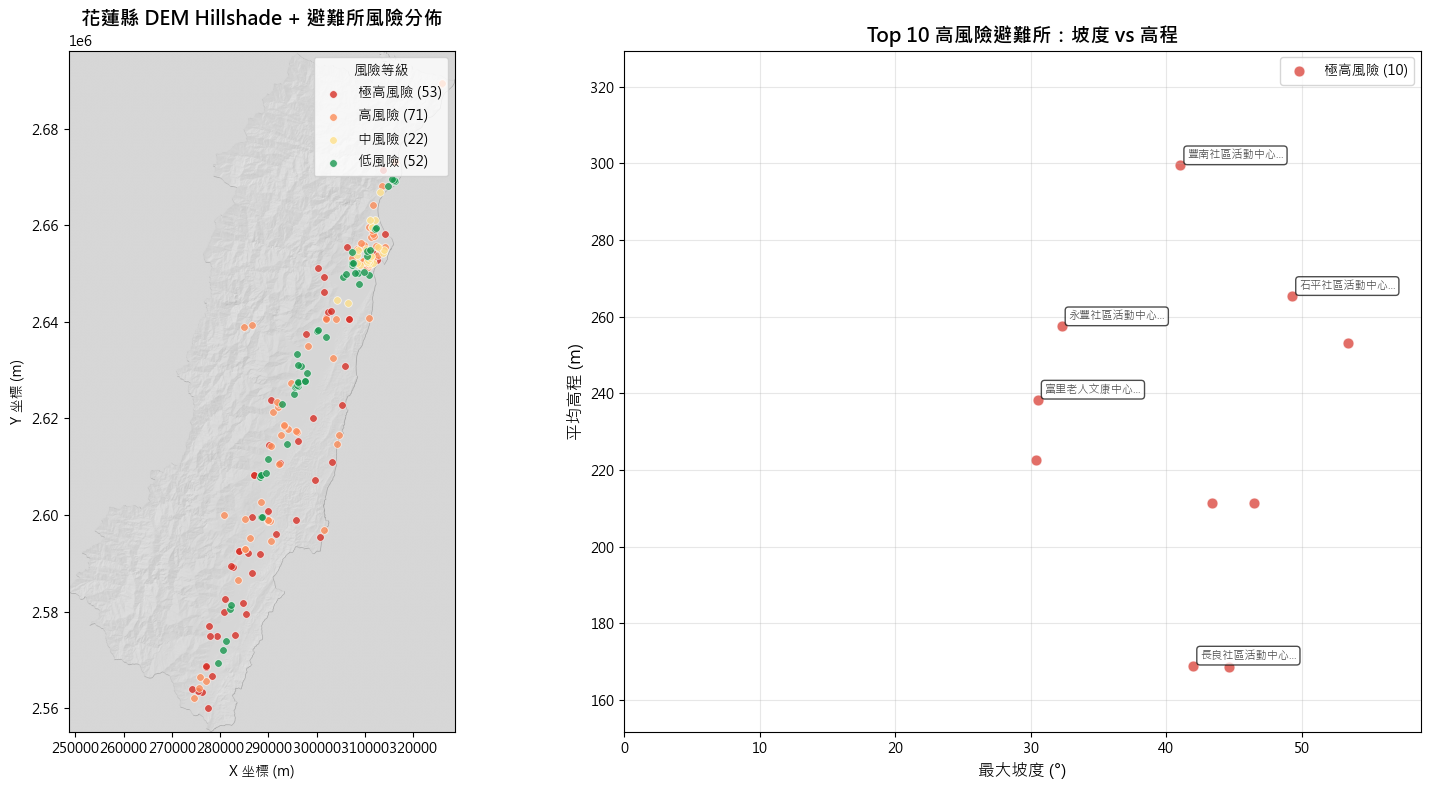

視覺化圖表已儲存為: terrain_risk_map.png
圖片解析度: 300 DPI
高風險避難所總數: 124
Top 10 高風險避難所已標示


In [36]:
# 視覺化 DEM + 避難所地圖
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import matplotlib.patches as mpatches

# 創建 2x1 子圖
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# === 左圖：DEM Hillshade + 避難所 ===
# 創建 hillshade
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem.values, vert_exag=0.1, dx=20, dy=20)

# 顯示 hillshade
im1 = ax1.imshow(hillshade, cmap='gray', extent=[dem.x.min(), dem.x.max(), dem.y.min(), dem.y.max()])
ax1.set_title(f'{TARGET_COUNTY} DEM Hillshade + 避難所風險分佈', fontsize=14, fontweight='bold')
ax1.set_xlabel('X 坐標 (m)')
ax1.set_ylabel('Y 坐標 (m)')

# 風險等級顏色映射
risk_colors = {
    '極高風險': '#d73027',
    '高風險': '#fc8d59', 
    '中風險': '#fee08b',
    '低風險': '#1a9850'
}

# 繪製避難所點（依風險等級著色）
for risk_level in risk_colors.keys():
    risk_shelters = county_shelters_with_risk[county_shelters_with_risk['risk_level'] == risk_level]
    if len(risk_shelters) > 0:
        # 轉換坐標
        x_coords = [geom.x for geom in risk_shelters.geometry]
        y_coords = [geom.y for geom in risk_shelters.geometry]
        ax1.scatter(x_coords, y_coords, 
                   c=risk_colors[risk_level], 
                   s=30, alpha=0.8, 
                   label=f'{risk_level} ({len(risk_shelters)})',
                   edgecolors='white', linewidth=0.5)

# 添加圖例
ax1.legend(title='風險等級', loc='upper right', bbox_to_anchor=(1, 1))

# === 右圖：Top 10 高風險避難所散佈圖 ===
# 篩選高風險和極高風險避難所
high_risk_shelters = county_shelters_with_risk[
    county_shelters_with_risk['risk_level'].isin(['高風險', '極高風險'])
].copy()

# 按風險程度排序（極高風險優先）
high_risk_shelters['risk_sort'] = high_risk_shelters['risk_level'].map({
    '極高風險': 0, '高風險': 1
})
high_risk_shelters = high_risk_shelters.sort_values('risk_sort')

# 取前10個
top10_high_risk = high_risk_shelters.head(10)

# 繪製散佈圖
risk_colors_scatter = {'極高風險': '#d73027', '高風險': '#fc8d59'}
for risk_level in ['極高風險', '高風險']:
    risk_data = top10_high_risk[top10_high_risk['risk_level'] == risk_level]
    if len(risk_data) > 0:
        ax2.scatter(risk_data['max_slope'], risk_data['mean_elevation'],
                   c=risk_colors_scatter[risk_level], 
                   s=60, alpha=0.7, 
                   label=f'{risk_level} ({len(risk_data)})',
                   edgecolors='white', linewidth=0.5)

# 添加避難所名稱標籤（前5個）
for i, (_, shelter) in enumerate(top10_high_risk.head(5).iterrows()):
    ax2.annotate(shelter['避難收容處所名稱'][:8] + '...', 
                (shelter['max_slope'], shelter['mean_elevation']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax2.set_xlabel('最大坡度 (°)', fontsize=12)
ax2.set_ylabel('平均高程 (m)', fontsize=12)
ax2.set_title(f'Top 10 高風險避難所：坡度 vs 高程', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 設定坐標範圍
ax2.set_xlim(0, max(top10_high_risk['max_slope']) * 1.1)
ax2.set_ylim(min(top10_high_risk['mean_elevation']) * 0.9, 
             max(top10_high_risk['mean_elevation']) * 1.1)

plt.tight_layout()

# 儲存圖片
output_file = 'terrain_risk_map.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"視覺化圖表已儲存為: {output_file}")
print(f"圖片解析度: 300 DPI")
print(f"高風險避難所總數: {len(high_risk_shelters)}")
print(f"Top 10 高風險避難所已標示")